## Environment Setup & Package Imports

This section initializes the required libraries for our analytical workspace. We load standard data manipulation tools, system file path managers, mathematical engines, visualization toolkits, and specialized parsing libraries to execute our data extraction, structural analysis, and visual diagnostics pipeline:

*   **re**: Provides regular expression tools for robust pattern matching, text token isolation, and filtering out repetitive PDF or formatting artifacts.
*   **json**: Provides standard tools to handle structured lexicon data serialization, hyperparameter tracking, and state configurations.
*   **numpy (np)**: Supports high-performance numeric arrays, vector arithmetic calculations, column-wise arithmetic means, and vector length normalizations.
*   **pandas (pd)**: Configures data frames to structure, index, aggregate, and organize raw paragraph chunks into clean tabular data matrices.
*   **pathlib.Path**: Handles safe, object-oriented, cross-platform system file path configurations across differing execution environments.
*   **matplotlib.pyplot (plt)**: Introduces fundamental plotting state machines used to initialize graphics canvas structures, define dimensions, and handle tight layout parameters.
*   **matplotlib.ticker.FuncFormatter**: Supplies dynamic axis label tools to cleanly scale and format large numeric intervals for executive charts.
*   **seaborn (sns)**: Supplies advanced statistical data visualization interfaces to cleanly chart overall probability densities (KDEs) and categorical boxplot ranking matrices.
*   **scipy.stats (stats)**: Connects our workspace to advanced scientific computing modules to run distribution profiling, mathematical modeling, and baseline statistical testing.
*   **warnings**: Configures global runtime execution controls to filter out noisy, non-breaking library updates (e.g., FutureWarning) to maintain clean and scannable notebook logs.

In [1]:
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import scipy.stats as stats

import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

## Import chunked_paragraphs_with_embeddings_uncer df

In [2]:
chunked_pg_w_embed_uncert = pd.read_csv("data_files/chunked_paragraphs_with_embeddings_uncert.csv")

chunked_pg_w_embed_uncert = chunked_pg_w_embed_uncert[
    chunked_pg_w_embed_uncert["subcategory"].astype(str).str.strip().str.lower()
    ==
    chunked_pg_w_embed_uncert["matched_phrase"].astype(str).str.strip().str.lower()
].copy()

print(chunked_pg_w_embed_uncert["subcategory"].unique())

chunked_pg_w_embed_uncert.head(5)

['Nondefense Discretionary' 'Social Security' 'Medicaid' 'Net Interest'
 'Medicare' 'Other Mandatory' 'Total Discretionary'
 'Defense Discretionary' 'Total Mandatory']


,report_name,paragraph_number,text,subcategory,row_id,match_method,matched_phrase,category,component,contextual_uncertainty_score
0,2000-01-01__12069__The Budget and Economic Out...,10,Dan L. Crippen Director January 2000 This stud...,Nondefense Discretionary,9,direct_phrase_w2v_neighbors,Nondefense Discretionary,Discretionary,outlay,0.022607
6,2000-01-01__12069__The Budget and Economic Out...,19,"Regardless of the variant, the budgetary pictu...",Social Security,18,direct_phrase_w2v_neighbors,Social Security,Mandatory,outlay,0.021429
28,2000-01-01__12069__The Budget and Economic Out...,49,Discretionary spending is projected to increas...,Nondefense Discretionary,48,direct_phrase_w2v_neighbors,Nondefense Discretionary,Discretionary,outlay,0.016471
40,2000-01-01__12069__The Budget and Economic Out...,83,To illustrate the possible effects of differen...,Medicaid,82,direct_phrase_w2v_neighbors,Medicaid,Mandatory,outlay,0.092086
46,2000-01-01__12069__The Budget and Economic Out...,89,CBO’s latest budget outlook is considerably mo...,Net Interest,88,direct_phrase_w2v_neighbors,Net Interest,Net Interest,outlay,0.019937


## Import CBO projection errors df from GitHub 

In [3]:
proj_errors = pd.read_csv("https://raw.githubusercontent.com/US-CBO/eval-projections/main/output_data/outlay_projection_errors.csv")

In [4]:
# Create absolute projection errors
# We only care about the magnitude of the error, not the direction
proj_errors["abs_projection_error"] = proj_errors["projection_error"].abs()

# Econometric Data Alignment: Merging Narrative Uncertainty and Projection Errors

This section coordinates the structural alignment of our two primary analytical datasets: the paragraph-level text dataset containing calculated contextual uncertainty scores, and the historical Congressional Budget Office (CBO) forecasting errors dataset retrieved from GitHub. 

---

## Data Integration Architecture

The merging pipeline standardizes timelines and taxonomies across both inputs before generating the final combined matrix:

```text
  [Uncertainty Paragraph Data]                  [CBO Projection Errors Data]
               │                                              │
               ▼                                              ▼
  ┌──────────────────────────┐                  ┌──────────────────────────┐
  │  Parse 'report_year'     │                  │  Parse 'baseline_year'   │
  │  via Regex: r'^(\d{4})'  │                  │  via datetime string     │
  └────────────┬─────────────┘                  └────────────┬─────────────┘
               │                                              │
               ▼                                              ▼
  ┌──────────────────────────┐                  ┌──────────────────────────┐
  │  Lowercase/Strip Strings │                  │  Lowercase/Strip Strings │
  │   ('subcategory')        │                  │   ('subcategory')        │
  └────────────┬─────────────┘                  └────────────┬─────────────┘
               │                                              │
               └──────────────────────┬───────────────────────┘
                                      │
                                      ▼
                        ┌───────────────────────────┐
                        │   pd.merge(how='inner')   │
                        │   Keys: Year, Category    │
                        └─────────────┬─────────────┘
                                      │
                                      ▼
                        ┌───────────────────────────┐
                        │ Calculate Forecast Horizon│
                        │ (Target Year - Pub Year)  │
                        └─────────────┬─────────────┘
                                      │
                                      ▼
                        [Unified Econometric Matrix File]
```

### 1. Temporal Standardization
Narrative Track: Extracting the four-digit publication year directly from the prefix of the file name string using a bounded Regular Expression pattern:
$$\text{Report Year}_i = \mathcal{R}\left(\text{report\_name}_i, \,\text{r}^\prime\wedge(\backslash\text{d}\{4\})\text{}^\prime\right)$$

### 2. Text Normalization
Standardizes the category names across both datasets by forcing them to text, stripping hidden spaces, and flattening all letters to lowercase to guarantee a perfect data match.

### 3. Forecast Horizon Evaluation
Calculates the dynamic lookahead horizon variable, establishing a clear temporal delta that lets us evaluate how narrative uncertainty scales over short-term vs. long-term projections:
$$\text{Projection Horizon (Years)} = \text{projected\_fiscal\_fiscal\_year} - \text{report\_year}$$

In [5]:
# =====================================================================
# 1. TEMPORAL VECTOR EXTRACTION & STANDARDIZATION
# =====================================================================
print("⏳ Extracting temporal alignment vectors from data sources...")

# GitHub error
# Isolate the baseline calculation year from the GitHub error matrix
proj_errors['temp_baseline_dt'] = pd.to_datetime(proj_errors['baseline_date'], errors='coerce')
proj_errors['baseline_year'] = proj_errors['temp_baseline_dt'].dt.year

# Chunked paragraphs with embedding uncertainty
# Parse numerical publication years from text filenames using regular expression flags
year_pattern = r'^(\d{4})'
chunked_pg_w_embed_uncert['report_year'] = chunked_pg_w_embed_uncert['report_name'].str.extract(year_pattern)[0]
chunked_pg_w_embed_uncert['report_year'] = pd.to_numeric(chunked_pg_w_embed_uncert['report_year'], errors='coerce')


# =====================================================================
# 2. TEXT NORMALIZATION & CASE-INSENSITIVE STANDARDIZATION
# =====================================================================
# Standardize text strings to eliminate match drops due to trailing whitespace or case anomalies
proj_errors['subcategory'] = proj_errors['subcategory'].astype(str).str.strip().str.lower()
chunked_pg_w_embed_uncert['subcategory'] = chunked_pg_w_embed_uncert['subcategory'].astype(str).str.strip().str.lower()


# =====================================================================
# 3. DUAL-KEY MATRIX MERGE LAYER
# =====================================================================
print("🔄 Executing multi-index inner join over year and subcategory")

# Map report publication timelines directly against baseline forecast timelines
merged_df = pd.merge(
    chunked_pg_w_embed_uncert,
    proj_errors[['baseline_year', 'subcategory', 'projected_fiscal_year', 'abs_projection_error']],
    left_on=['report_year', 'subcategory'],
    right_on=['baseline_year', 'subcategory'],
    how='inner'  # Inner join isolates structural matches; change to 'left' to retain unpaired text chunks
)


# =====================================================================
# 4. FORECAST HORIZON HORIZONTAL METRIC ENGINE
# =====================================================================
# Calculate the lookahead span (Target Projection Year minus Baseline Publication Year)
merged_df['projected_fiscal_year'] = pd.to_numeric(merged_df['projected_fiscal_year'], errors='coerce')
merged_df['projection_horizon_years'] = merged_df['projected_fiscal_year'] - merged_df['report_year']


# =====================================================================
# 5. CLEAN UP DATAFRAME AFTER MERGING
# =====================================================================
# Drop redundant internal join keys and temporary alignment vectors from memory
columns_to_drop = ['baseline_year', 'extracted_date', 'temp_datetime', 'year_month_key']
merged_df = merged_df.drop(columns=columns_to_drop, errors='ignore')

# Render industrial execution verification summary console table
print("\n" + "="*70)
print("                  DATA ALIGNMENT PIPELINE RUN REPORT                  ")
print("="*70)
print(f"  • Enriched Matrix Dimensions    : {merged_df.shape[0]:,} Rows × {merged_df.shape[1]} Columns")
print(f"  • Min / Max Recorded Horizons  : {merged_df['projection_horizon_years'].min():.0f} to {merged_df['projection_horizon_years'].max():.0f} Years Out")
print(f"  • Unique Program Classifications : {merged_df['subcategory'].nunique()}")
print("=" * 70)

preview_cols = ['report_name', 'subcategory', 'projected_fiscal_year', 'projection_horizon_years', 'abs_projection_error']
merged_df[preview_cols].head(5)

⏳ Extracting temporal alignment vectors from data sources...
🔄 Executing multi-index inner join over year and subcategory

                  DATA ALIGNMENT PIPELINE RUN REPORT                  
  • Enriched Matrix Dimensions    : 36,088 Rows × 14 Columns
  • Min / Max Recorded Horizons  : 0 to 10 Years Out
  • Unique Program Classifications : 9


,report_name,subcategory,projected_fiscal_year,projection_horizon_years,abs_projection_error
0,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2000,0,13.415
1,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2001,1,4.696
2,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2002,2,2.649
3,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2003,3,6.871
4,2000-01-01__12069__The Budget and Economic Out...,nondefense discretionary,2004,4,12.100


## Drop any subcategory that contains "total" case-insensitive

In [6]:
mask_drop = merged_df["subcategory"].astype(str).str.contains(
    "total",
    case=False,
    na=False,
    regex=False
)

merged_df = merged_df[~mask_drop].copy()

# Check remaining subcategories
merged_df["subcategory"].unique()

merged_df.to_csv("data_files/projection_error_uncertainty.csv", index=False)

## Project Overview
This section calculates and visualizes correlations across our budget subcategories. By calculating the correlation between our paragraph-level text uncertainty density and historical absolute projection errors, we evaluate whether expressing uncertainty in our reports is correlated to historical projection errors. 

---

## Statistical & Visual Architecture

The analytical pipeline isolates and maps programmatic features through the following core operational layers:

### 1. Non-Parametric Correlation Engine
The script filters out missing variables, groups data by subcategory, and enforces a minimum condition of three historical data points before running a Spearman rank correlation. This non-parametric approach safely handles skewed or non-linear distributions to isolate stable structural signals.

### 2. Alpha-Level Significance Categorization
Calculated probability coefficients ($p$-values) are passed through an automated validation gateway to assign explicit significance tags. Program areas settling below our alpha ceiling ($p < 0.05$) are flagged as statistically significant, while weak or sample-deficient matrices are filtered out.

### 3. Absolute Magnitude Ranking & Color Mapping
The final table is sorted by absolute correlation magnitude to highlight the primary drivers and is plotted on a horizontal canvas.

In [7]:
# =====================================================================
# 1. DROP NULL ROWS
# =====================================================================
# Drop rows with missing subcategory, sentiment scores or projection error observations
clean_df = merged_df[['subcategory', 'contextual_uncertainty_score', 'abs_projection_error']].dropna()


# =====================================================================
# 2. STATISTICAL ENGINE: Non-Parametric Spearman Rho Inversions
# =====================================================================
sub_results = []

for subcat, group in clean_df.groupby('subcategory'):
    n_samples = len(group)
    
    # Establish a minimum boundary condition (n >= 3) to execute meaningful correlations
    if n_samples >= 3:
        coef, p_val = stats.spearmanr(group['contextual_uncertainty_score'], group['abs_projection_error'])
    else:
        coef, p_val = None, None
        
    sub_results.append({
        'subcategory': subcat,
        'sample_size': n_samples,
        'spearman_rho': coef,
        'p_value': p_val
    })

# Restructure active dictionary cache map array into a formal tabular DataFrame matrix
subcategory_correlations = pd.DataFrame(sub_results)


# =====================================================================
# 3. EMPIRICAL FILTERS: Statistical Significance Labeling
# =====================================================================
def check_sig(p):
    """
    Categorizes calculated continuous p-values into discrete alpha-level significance brackets.
    """
    if p is None:
        return 'Insufficient Samples (< 3)'
    elif p < 0.01:
        return 'Highly Significant (p < 0.01) **'
    elif p < 0.05:
        return 'Significant (p < 0.05) *'
    else:
        return 'Not Statistically Significant'

subcategory_correlations['significance'] = subcategory_correlations['p_value'].apply(check_sig)


# =====================================================================
# 4. DATA SORTING & INVENTORY RESHAPING
# =====================================================================
# Rank rows by the magnitude of absolute association coefficients to bubble up top drivers
subcategory_correlations['abs_rho'] = subcategory_correlations['spearman_rho'].abs()

subcategory_correlations = (
    subcategory_correlations
    .sort_values(by='abs_rho', ascending=False)
    .drop(columns=['abs_rho'])
    .reset_index(drop=True)
)

# Display final formatted summary breakdown matrix
subcategory_correlations

,subcategory,sample_size,spearman_rho,p_value,significance
0,medicaid,3715,-0.087941,7.931067e-08,Highly Significant (p < 0.01) **
1,medicare,4188,0.082818,7.996803e-08,Highly Significant (p < 0.01) **
2,net interest,6490,-0.034358,5.637584e-03,Highly Significant (p < 0.01) **
3,other mandatory,1758,0.022183,3.526061e-01,Not Statistically Significant
4,nondefense discretionary,2468,0.011966,5.524085e-01,Not Statistically Significant
5,social security,15822,-0.011211,1.585096e-01,Not Statistically Significant
6,defense discretionary,278,0.000574,9.923921e-01,Not Statistically Significant


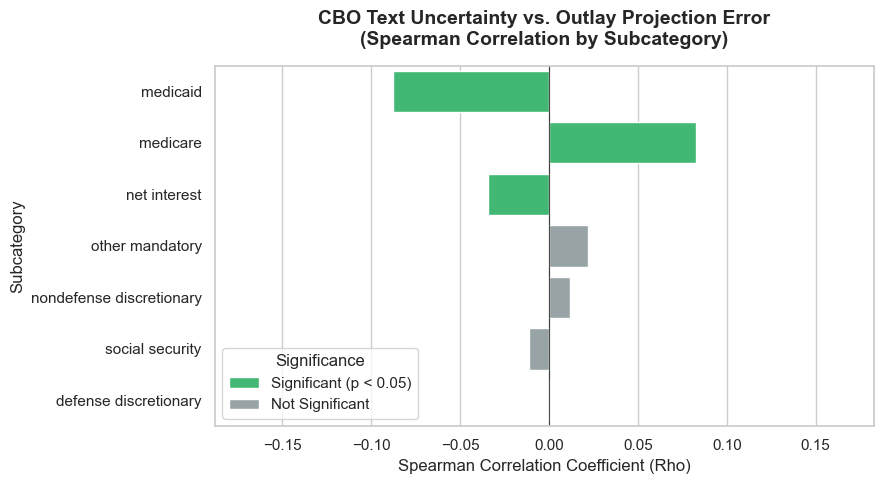

In [8]:
# =====================================================================
# 0. DATA PREPARATION & MATRIX SORTING
# =====================================================================
# Filter out sparse records lacking calculated continuous correlation coefficients
viz_df = subcategory_correlations.dropna(subset=['spearman_rho']).copy()

# Sort data rows by absolute magnitude to prioritize strong structural relationships
viz_df['abs_rho'] = viz_df['spearman_rho'].abs()
viz_df = viz_df.sort_values(by='abs_rho', ascending=False)

# Partition calculated p-values into discrete categories to drive plot logic mapping
viz_df['Significance'] = viz_df['p_value'].apply(
    lambda p: 'Significant (p < 0.05)' if p < 0.05 else 'Not Significant'
)


# =====================================================================
# 1. VISUALIZATION CANVAS DEPLOYMENT
# =====================================================================
# Configure professional corporate theme constraints
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# --- Horizontal Barplot Matrix Generation ---
# Maps emerald green tones to statistical signals and slate grey to insignificant pairings
sns.barplot(
    data=viz_df,
    x='spearman_rho',
    y='subcategory',
    hue='Significance',
    palette={
        'Significant (p < 0.05)': '#2ecc71',  # Emerald green
        'Not Significant': '#95a5a6'          # Slate grey
    },
    dodge=False
)


# =====================================================================
# 2. AXIS LAYOUT & LABELS ENGINEERING
# =====================================================================
# Establish a strict vertical zero-axis reference coordinate frame
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)

# Apply formal descriptive labels and text geometry parameters
plt.title('CBO Text Uncertainty vs. Outlay Projection Error\n(Spearman Correlation by Subcategory)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Spearman Correlation Coefficient (Rho)', fontsize=12)
plt.ylabel('Subcategory', fontsize=12)

# Dynamically scale x-axis boundaries to provide uniform padding buffers
min_val = viz_df['spearman_rho'].min()
max_val = viz_df['spearman_rho'].max()
plt.xlim(min_val - 0.1 if min_val < 0 else -0.1, max_val + 0.1 if max_val > 0 else 0.1)

# Clean rendering margins and deploy the final canvas graphic
plt.tight_layout()
plt.show()

## Project Overview
This section tracks how the relationship between text uncertainty and forecast errors changes across different planning windows: short-term (3 years out), medium-term (6 years out), and long-term (9 years out). 

---

## Forecast Horizon Visualization Architecture

The graphing function processes and displays the data using three simple steps:

### 1. Calculating the Target Forecast Year
The code creates a new timeline variable called the "forecast year" by adding the lookahead horizon to the report's publication year ($Y_{\text{publication}} + H_{\text{years}}$). Mapping the data this way lets us look directly at the specific calendar year being projected, making it easy to line up what the CBO said with the actual fiscal outcome.

### 2. Splitting into Two Y-Axes
Because text uncertainty scores are percentages and budget errors are raw numbers, each chart uses two separate vertical scales. The left scale displays average text uncertainty as a clean percentage using corporate blue lines, while the right scale displays the average absolute projection error as a standard number using distinct crimson lines.

### 3. Cleaning the Timeline and Running the Loop
To prevent the charts from looking cluttered or mismatched, the code automatically finds the earliest and latest years in the data to create an evenly spaced, rotated timeline grid. It then loops through our main budget categories—Medicaid, Medicare, and Net Interest—to automatically generate standardized, side-by-side charts for each one.

📊 Deploying dual-axis time-series visualizations across target programs...


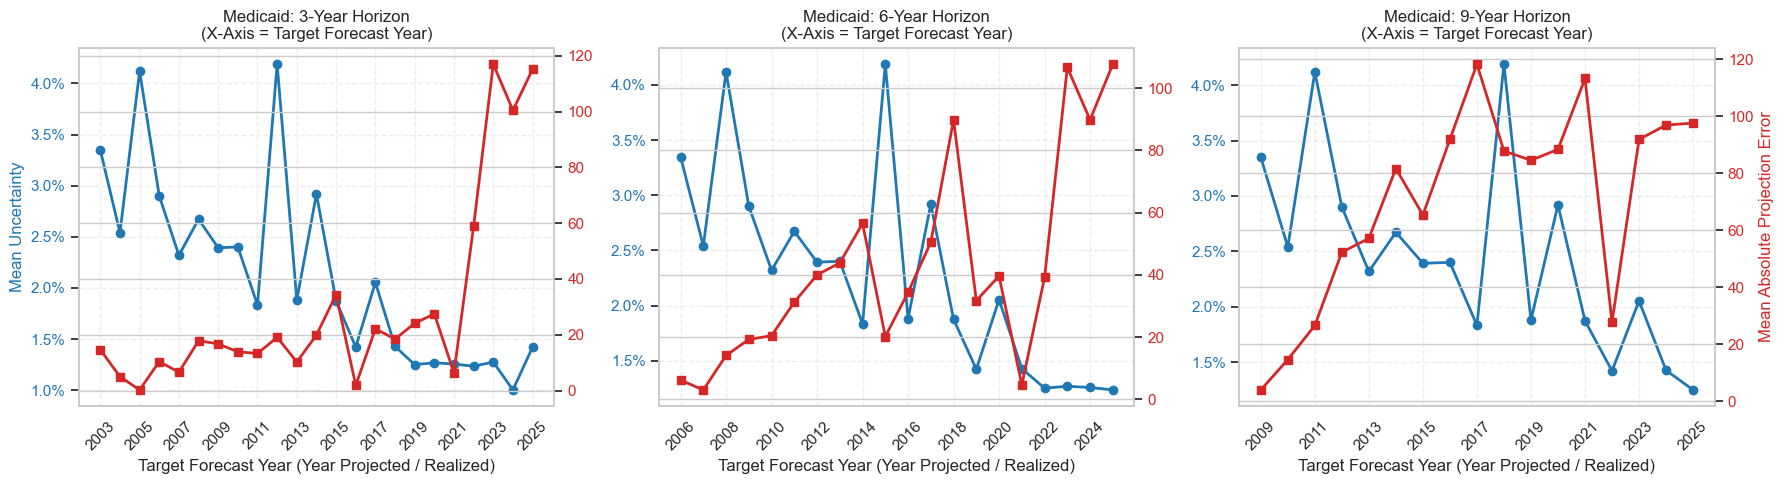

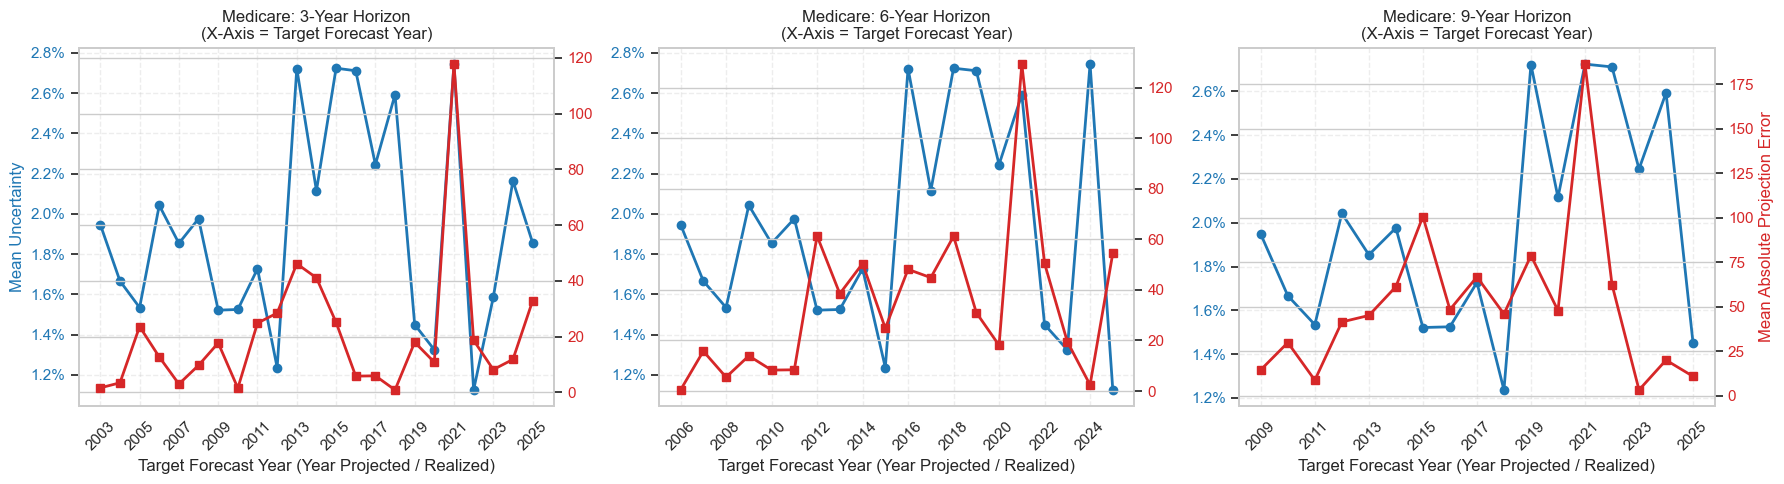

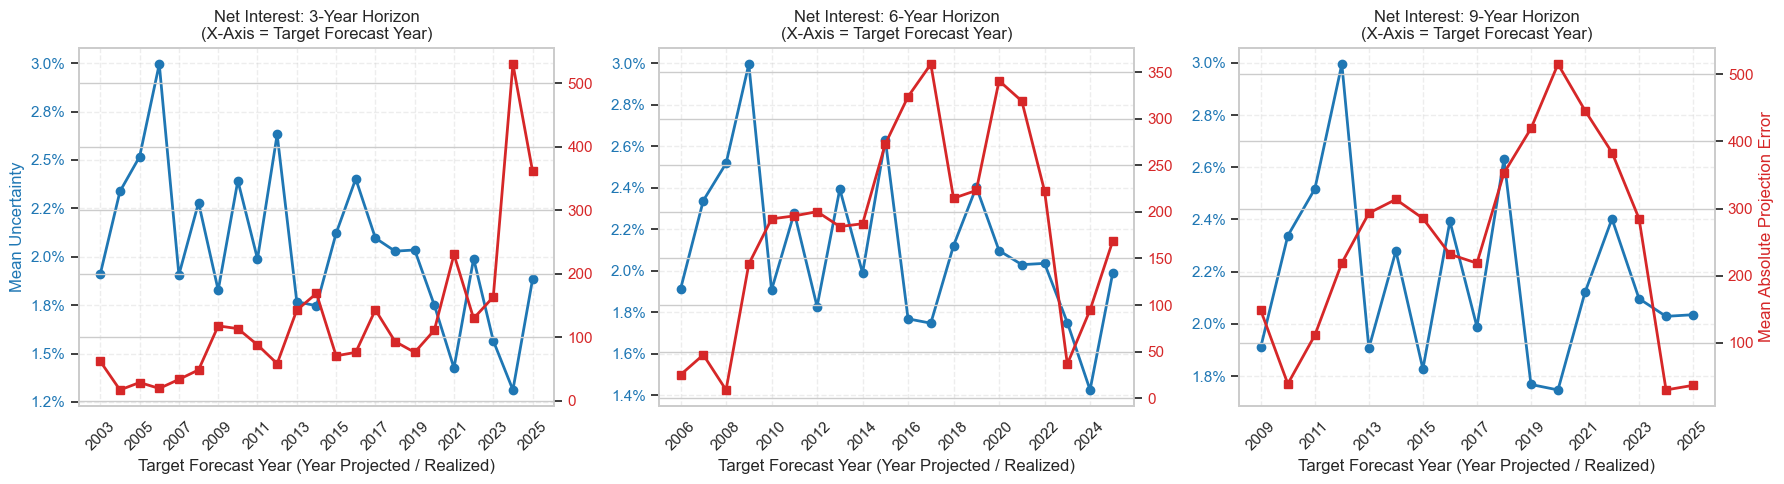

In [9]:
# =====================================================================
# 0. PARAMETER DEFINITIONS
# =====================================================================
# Target programs and forecast spans to evaluate within the modeling script
subs = ['medicaid', 'medicare', 'net interest']
horizons = [3, 6, 9]


# =====================================================================
# 1. TIME-SERIES VISUALIZATION ENGINE (DUAL-AXIS DISTRIBUTION)
# =====================================================================
def plot_uncertainty_vs_error_by_forecast_year_from_merged(
    merged_df,
    program="medicaid",
    horizons=(3, 6, 9),
    score_col="contextual_uncertainty_score",
    err_col="abs_projection_error",
    show_uncertainty_as_percent=True,
    year_tick_step=2,
):
    """
    Generates a multi-panel subplot canvas graphing mean narrative uncertainty 
    against realized absolute projection error, plotted against the target forecast year.
    """
    # Create isolated copy of working dataframe matrix to avoid altering data references
    d0 = merged_df.copy()

    # Text Normalization: Eliminate formatting mismatches on the key field
    d0["subcategory"] = d0["subcategory"].astype(str).str.strip().str.lower()
    program = str(program).strip().lower()

    # Filter matrix by the selected programmatic target segment
    d0 = d0[d0["subcategory"].eq(program)].copy()
    
    # Prune non-finite structural elements across tracking columns
    d0 = d0.dropna(subset=["report_year", score_col, err_col, "projection_horizon_years"])

    # Enforce strict numerical datatypes for calculations
    d0["report_year"] = pd.to_numeric(d0["report_year"], errors="coerce")
    d0["projection_horizon_years"] = pd.to_numeric(d0["projection_horizon_years"], errors="coerce")
    d0 = d0.dropna(subset=["report_year", "projection_horizon_years"])

    d0["report_year"] = d0["report_year"].astype(int)
    d0["projection_horizon_years"] = d0["projection_horizon_years"].astype(int)

    # Calculate target forecast year (Publication Year + Lookahead Span)
    d0["forecast_year"] = d0["report_year"] + d0["projection_horizon_years"]

    # Initialize horizontal canvas subplots
    fig, axes = plt.subplots(1, len(horizons), figsize=(18, 5), sharex=False)
    if len(horizons) == 1:
        axes = [axes]

    # Initialize custom formatting functions for left and right axis elements
    unc_fmt = FuncFormatter(lambda y, _: f"{100*y:.1f}%") if show_uncertainty_as_percent else FuncFormatter(lambda y, _: f"{y:.3f}")
    err_fmt = FuncFormatter(lambda y, _: f"{y:,.0f}")

    # Iteratively deploy independent visual panels per lookahead horizon
    for i, H in enumerate(horizons):
        ax = axes[i]

        # Isolate the current horizon subset slice
        d = d0[d0["projection_horizon_years"].eq(H)].copy()
        if d.empty:
            ax.set_title(f"{program.title()}: Horizon {H} (Insufficient Data)")
            ax.axis("off")
            continue

        # Aggregate matrix records to target forecast year center-mass values
        plot_df = (
            d.groupby("forecast_year", as_index=False)
             .agg(
                 mean_uncertainty=(score_col, "mean"),
                 paragraph_count=(score_col, "size"),
                 abs_projection_error=(err_col, "mean"),
                 mean_baseline_year=("report_year", "mean"),
             )
             .sort_values("forecast_year")
        )

        # --- Primary Axis (Left Hand): Narrative Uncertainty Plot ---
        ax.plot(plot_df["forecast_year"], plot_df["mean_uncertainty"],
                marker="o", linewidth=2, color="#1f77b4")
        ax.set_title(f"{program.title()}: {H}-Year Horizon\n(X-Axis = Target Forecast Year)")
        ax.set_xlabel("Target Forecast Year (Year Projected / Realized)")
        
        if i == 0:
            ax.set_ylabel("Mean Uncertainty", color="#1f77b4")
            
        ax.tick_params(axis="y", labelcolor="#1f77b4")
        ax.yaxis.set_major_formatter(unc_fmt)
        ax.grid(True, linestyle="--", alpha=0.35)

        # Generate evenly spaced ticks for chronological timeline scaling
        years = plot_df["forecast_year"].to_numpy()
        if len(years) > 0:
            start = int(years.min())
            end = int(years.max())
            ax.set_xticks(list(range(start, end + 1, year_tick_step)))
            
        ax.tick_params(axis="x", rotation=45)

        # --- Secondary Axis (Right Hand): Absolute Forecast Error Plot ---
        ax2 = ax.twinx()
        ax2.plot(plot_df["forecast_year"], plot_df["abs_projection_error"],
                 marker="s", linewidth=2, color="#d62728")
        
        if i == len(horizons) - 1:
            ax2.set_ylabel("Mean Absolute Projection Error", color="#d62728")
            
        ax2.tick_params(axis="y", labelcolor="#d62728")
        ax2.yaxis.set_major_formatter(err_fmt)

    # Clean rendering boundaries and draw final visual charts to the screen
    plt.tight_layout()
    plt.show()


# =====================================================================
# 2. COORDINATED CANVAS DISTRIBUTION LOOPS
# =====================================================================
print("📊 Deploying dual-axis time-series visualizations across target programs...")

for sub in subs:
    plot_uncertainty_vs_error_by_forecast_year_from_merged(
        merged_df=merged_df, 
        program=sub, 
        horizons=horizons, 
        show_uncertainty_as_percent=True
    )

### Plot Medicaid for 3-year horizon (top left graph) for putting this plot to poster

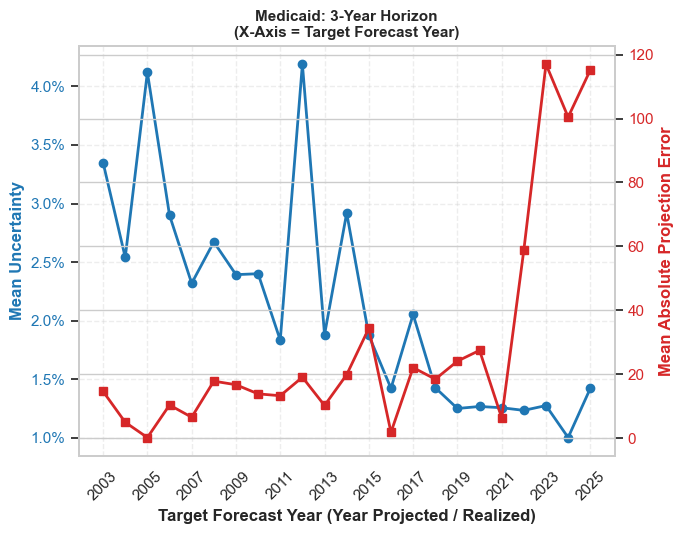

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

def plot_medicaid_3yr_single_panel(
    merged_df,
    score_col="contextual_uncertainty_score",
    err_col="abs_projection_error",
    show_uncertainty_as_percent=True,
    year_tick_step=2,
):
    """
    Generates a single standalone dual-axis figure for Medicaid (3-Year Horizon)
    with explicit left and right y-axis labels.
    """
    # Create isolated copy of working dataframe matrix
    d0 = merged_df.copy()

    # Text Normalization & Filtering
    d0["subcategory"] = d0["subcategory"].astype(str).str.strip().str.lower()
    d0 = d0[d0["subcategory"].eq("medicaid")].copy()
    
    # Prune non-finite structural elements
    d0 = d0.dropna(subset=["report_year", score_col, err_col, "projection_horizon_years"])

    # Enforce strict numerical datatypes
    d0["report_year"] = pd.to_numeric(d0["report_year"], errors="coerce").astype(int)
    d0["projection_horizon_years"] = pd.to_numeric(d0["projection_horizon_years"], errors="coerce").astype(int)

    # Filter specifically for the 3-Year Horizon
    d0 = d0[d0["projection_horizon_years"].eq(3)].copy()

    # Calculate target forecast year
    d0["forecast_year"] = d0["report_year"] + d0["projection_horizon_years"]

    # Initialize single panel canvas
    fig, ax1 = plt.subplots(figsize=(7, 5.5))

    # Formatters
    unc_fmt = FuncFormatter(lambda y, _: f"{100*y:.1f}%") if show_uncertainty_as_percent else FuncFormatter(lambda y, _: f"{y:.3f}")
    err_fmt = FuncFormatter(lambda y, _: f"{y:,.0f}")

    # Aggregate data points
    plot_df = (
        d0.groupby("forecast_year", as_index=False)
          .agg(
              mean_uncertainty=(score_col, "mean"),
              abs_projection_error=(err_col, "mean")
          )
          .sort_values("forecast_year")
    )

    # --- Primary Axis (Left Hand): Narrative Uncertainty Plot ---
    color_blue = "#1f77b4"
    ax1.plot(plot_df["forecast_year"], plot_df["mean_uncertainty"],
             marker="o", linewidth=2, color=color_blue)
    ax1.set_title("Medicaid: 3-Year Horizon\n(X-Axis = Target Forecast Year)", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Target Forecast Year (Year Projected / Realized)", fontweight="bold")
    ax1.set_ylabel("Mean Uncertainty", color=color_blue, fontweight="bold")
    ax1.tick_params(axis="y", labelcolor=color_blue)
    ax1.yaxis.set_major_formatter(unc_fmt)
    ax1.grid(True, linestyle="--", alpha=0.35)

    # Generate evenly spaced ticks for X-axis
    years = plot_df["forecast_year"].to_numpy()
    if len(years) > 0:
        start = int(years.min())
        end = int(years.max())
        ax1.set_xticks(list(range(start, end + 1, year_tick_step)))
    ax1.tick_params(axis="x", rotation=45)

    # --- Secondary Axis (Right Hand): Absolute Forecast Error Plot ---
    ax2 = ax1.twinx()
    color_red = "#d62728"
    ax2.plot(plot_df["forecast_year"], plot_df["abs_projection_error"],
             marker="s", linewidth=2, color=color_red)
    
    # Explicitly set the right-hand Y-axis label
    ax2.set_ylabel("Mean Absolute Projection Error", color=color_red, fontweight="bold")
    ax2.tick_params(axis="y", labelcolor=color_red)
    ax2.yaxis.set_major_formatter(err_fmt)

    # Adjust layout to ensure labels fit cleanly
    plt.tight_layout()
    plt.savefig("medicaid_3yr_dual_axis.png", dpi=300, bbox_inches="tight")
    plt.show()

# Execution Call
plot_medicaid_3yr_single_panel(merged_df)